# Technical Space Competitors
- Specifically, for Neok001 -> what patents could create blocking or design-around pressure  

But even in claims, you may see stealth and strategic drafting 
- For example, instead of using the explict naming of the target, they may use sequence identifications or structure-based claims
- To address both false negatives (strategic drafting) and false positives, independent claim text was analyzed using an AI-assisted classification pipeline
- The claims of each patent was extracted and submitted to an API-based AI model for labeling

**The model is used to detect and classify claims that involve:**
- Bispecific ADC constructs
- Antibodies targeting B7-H3
- Antibodies targeting ROR1 
- TOP1 payloads

_Under the working assumption that all records represent ADC and oncology-related inventions, due to prior CPC-based filtering performed in The Lens_

### **Scope Limitation**:
As mentioned previously, this analysis is restricted to the textual claim content
- Images (Drawings, chemical structure, etc) will not be examined
- Structure-image parsing is beyond the scope of the project

<br>

---

## Prompts for detecting same technical space

**<span style="background-color: yellow; color: black;">As mentioned in 5b-1 notebook, the AI API portion and the code cells below were ran in that course git hub repo folder.</span>**

**<span style="background-color: yellow; color: black;">Code cells starting at "Competitors to NEOK001" returns back to running on this repo</span>**

In [2]:
#Provide the developer prompt
instructions = """
You are a pharmaceutical patent analyst evaluating competitive risk to an ADC program targeting ROR1 or B7-H3 with a topoisomerase I inhibitor payload.

Core rules:
- Analyze CLAIMS first. Title and abstract are secondary.
- Base conclusions on claimed scope, not background discussion.
- Be conservative and evidence-based.
- Only assign medium/high confidence if claims clearly support it.
- Avoid over-inference from generic oncology language.

Return strict JSON only.
Keep reasoning concise but specific (3–4 sentences per section).
"""

In [ ]:
prompt = """
Analyze the following patent to determine if it poses competitive risk to an ADC program targeting:
- ROR1
- B7-H3
- A topoisomerase I inhibitor payload

TITLE:
{title}

ABSTRACT:
{abstract}

CLAIMS:
{claims}

==============================
STEP 1: Evaluate ROR1 targeting
==============================

HIGH confidence:
- Explicit mention of "ROR1", "NTRKR1", or full receptor name.
- Antibody claims specifying ROR1 binding.

MEDIUM confidence:
- Claims describing an orphan receptor tyrosine kinase with:
    • Wnt5a non-canonical signaling involvement
    • Expression in CLL or mantle cell lymphoma
    • Restricted normal adult expression
    • Binding to cysteine-rich or kringle domains
- Sequence-defined antibody clearly tied to that receptor.

LOW confidence:
- Sequence-defined antibody without clear antigen disclosure.

Do NOT flag:
- Generic tyrosine kinase
- Generic orphan receptor
- Generic B-cell antigen

==============================
STEP 2: Evaluate B7-H3 targeting
==============================

HIGH confidence:
- Explicit "B7-H3" or "CD276"
- Antibody claims specifying B7-H3 binding

MEDIUM confidence:
- Target described as 4Ig (IgV-IgC-IgV-IgC) B7 family member
- Overexpressed in neuroblastoma AND prostate AND lung/breast
- B7 family member explicitly NOT PD-L1, PD-L2, B7-H4, CTLA-4

LOW confidence:
- Sequence-defined antibody without antigen clarity

Do NOT flag:
- Generic immune checkpoint
- Generic B7 family language alone

CRITICAL DISAMBIGUATION - B7-H3 vs B7-H4:
- B7-H3 = CD276 → pro-tumorigenic, overexpressed in solid tumors, therapeutic target
- B7-H4 = VTCN1 = B7S1 → completely different protein and gene, do NOT flag as B7-H3
- If patent explicitly mentions B7-H4, VTCN1, or B7S1 → set b7h3_flag = false
- These are frequently confused — verify the exact target before flagging

==============================
STEP 3: Evaluate Topoisomerase I payload
==============================

HIGH confidence:
- Explicit DXd, SN-38, exatecan, irinotecan, topotecan, camptothecin, belotecan
- Explicit "topoisomerase I inhibitor" in payload claim

MEDIUM confidence:
- "Camptothecin derivative" or analog
- Payload described as causing DNA single-strand breaks via topo I trapping
- Structural description of camptothecin-like lactone scaffold

Do NOT flag:
- Generic DNA damage
- Generic cytotoxic payload
- Generic topoisomerase inhibitor (must specify Type I)

==============================
STEP 4: Evaluate Bispecific Constructs
==============================

bispecific_flag = true ONLY if:
- Claims describe a bispecific/multispecific antibody
AND
- One arm meets ROR1 or B7-H3 criteria above

==============================
STEP 5: Determine competitor_flag
==============================

Set competitor_flag = true ONLY if:
- ror1_flag is true with medium or high confidence
OR
- b7h3_flag is true with medium or high confidence
OR
- topo1_flag is true with medium or high confidence
OR
- bispecific_flag is true AND ROR1/B7-H3 confidence ≥ medium

If confidence is LOW only → competitor_flag = false
But note manual review in reasoning.

==============================
Return STRICT JSON:
==============================

{{
  "ror1_flag": true/false,
  "ror1_confidence": "high/medium/low/none",
  "ror1_reasoning": "",
  "b7h3_flag": true/false,
  "b7h3_confidence": "high/medium/low/none",
  "b7h3_reasoning": "",
  "topo1_flag": true/false,
  "topo1_confidence": "high/medium/low/none",
  "topo1_reasoning": "",
  "bispecific_flag": true/false,
  "bispecific_reasoning": "",
  "competitor_flag": true/false,
  "competitor_reasoning": ""
}}
"""

In [ ]:
def competitor_patent(row):
    filled_prompt = prompt.format(
        title=row['title'],
        abstract=row['abstract_text'],
        claims=row['claims_text']
    )
    
    response = client.chat.completions.create(
        model="gpt-4o", #Using 4o here for better reasoning on complex patent claims. Will be using composiiton patent subset later to reduce token usage and cost
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": filled_prompt}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    
    return json.loads(response.choices[0].message.content)

## API Validation Using a Manually Curated Patent Set

Again, ran it on ABL Bio Patent profile for validation and prompt tuning

**Critical disambiguation rule:**  
During ABL Bio validation testing, the model incorrectly flagged **B7-H4 (VTCN1)** patents as B7-H3 hits.
These are distinct proteins (CD276 vs VTCN1 / B7S1) so an explicit disambiguation rule was added to reject B7-H4 / VTCN1 / B7S1 matches.

Results of this is in `abl_patents_competitor_4o_mini_v3.csv`

## AI-assisted flagging on 1064 Composition Patents

In [ ]:
import pandas as pd

ai_input = pd.read_csv("patents_classified_v3mini.csv") #the results with composition labeling
patents_for_ai = pd.read_csv("patents_for_ai.csv") #what was inputted, which has title, abstract and claims text

In [ ]:
composition_ids = ai_input.loc[
    ai_input["patent_type"] == "Composition",
    "lens_id"
]

In [ ]:
composition_text = patents_for_ai[
    patents_for_ai["lens_id"].isin(composition_ids)
].copy()

In [ ]:
results = []
for idx, row in composition_text.iterrows():
    print(f"Processing {idx+1}/{len(composition_text)}: {row['lens_id']}")
    try:
        result = competitor_patent(row)
        result['lens_id'] = row['lens_id']
        results.append(result)
    except Exception as e:
        print(f"  Error: {e}")
        results.append({'lens_id': row['lens_id'], 'error': str(e)})

results_df = pd.DataFrame(results)
results_df.to_csv("patents_competitor_4o.csv", index=False)
print("Done!")
results_df.head()

In [ ]:
#Couple lines ran in limit of 30K TPM for gpt-4o 
error_ids = results_df[results_df['error'].notna()]['lens_id'].tolist()
error_df = composition_text[composition_text['lens_id'].isin(error_ids)]
print(f"Errors to rerun: {len(error_df)}")

#Errors to rerun: 16

In [ ]:
#Will truncate the claims for those 16 patents, to stay within token limits
def competitor_patent(row):
    claims = str(row['claims_text'])[:6000]  # truncate here
    filled_prompt = prompt.format(
        title=row['title'],
        abstract=row['abstract_text'],
        claims=claims  # use truncated version
    )
    
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": filled_prompt}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    
    return json.loads(response.choices[0].message.content)

In [ ]:
rerun_results = []
for idx, row in error_df.iterrows():
    print(f"Processing {row['lens_id']}")
    try:
        result = competitor_patent(row)
        result['lens_id'] = row['lens_id']
        rerun_results.append(result)
    except Exception as e:
        print(f"  Error: {e}")
        rerun_results.append({'lens_id': row['lens_id'], 'error': str(e)})
    
    
# combine with clean results
clean_df = results_df[results_df['error'].isna()]
rerun_df = pd.DataFrame(rerun_results)
final_df = pd.concat([clean_df, rerun_df], ignore_index=True)
final_df.to_csv("patents_targets_full.csv", index=False)
print(f"Total: {len(final_df)}")

---

# Competitors to NEOK001

After saving the `patents_targets_full.csv` in the course repo, I uploaded those results onto this repo in `/data/ai_results/patents_targets_full.csv`

**<span style="background-color: yellow; color: black;">The remaining code can now be run on this notebook</span>** 

This section is results after analyzing the 1,064 Composition patents that were passed through GPT-4o for competitor detection. Each patent was evaluated across four independent dimensions:

- **ROR1 targeting** — confidence: high / medium / low / none
- **B7-H3 targeting** — confidence: high / medium / low / none
- **Topo-I payload** — confidence: high / medium / low / none
- **Bispecific architecture** — boolean flag (claims describe a bispecific or multispecific antibody,  where one arm targets ROR1 or B7-H3)

## Load Data & Confidence Summary

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from matplotlib.patches import Patch

competitor_df = pd.read_csv("../../data/ai_results/patents_targets_full.csv")

print(f"Total patents analyzed: {len(competitor_df)}")
print()
print("ROR1 confidence:")
print(competitor_df['ror1_confidence'].value_counts())
print("\nB7-H3 confidence:")
print(competitor_df['b7h3_confidence'].value_counts())
print("\nTopo-I confidence:")
print(competitor_df['topo1_confidence'].value_counts())
print("\nBispecific flag (pre-correction):")
print(competitor_df['bispecific_flag'].value_counts())
print(f"\nAI-flagged competitors: {competitor_df['competitor_flag'].sum()}")

Total patents analyzed: 1057

ROR1 confidence:
ror1_confidence
none      1029
high        27
medium       1
Name: count, dtype: int64

B7-H3 confidence:
b7h3_confidence
none      997
high       58
medium      2
Name: count, dtype: int64

Topo-I confidence:
topo1_confidence
none      910
high      111
medium     23
low        13
Name: count, dtype: int64

Bispecific flag (pre-correction):
bispecific_flag
False    1041
True       16
Name: count, dtype: int64

AI-flagged competitors: 187



- **Topo-I dominates** — 134 patents flagged (111 high, 23 medium)
- **B7-H3 second** — 60 patents (58 high, 2 medium)
- **ROR1 smallest** — only 28 patents (27 high, 1 medium), consistent with ROR1 being the less clinically mature ADC target
- **Bispecific** — 16 patents flagged (pre-correction; see below)

## Classifier Correction - Bispecific Flag Audit

Cross-tabulating `bispecific_flag` against target confidence revealed that the AI flagged 16 patents as bispecific, but 12 of those had their own reasoning text correctly noting neither arm targets ROR1 or B7-H3 (e.g. DLL3/CD3, EGFR/HER3, PD-1/CTLA4 bispecifics).

This violated Step 4 of the prompt which required `bispecific_flag` to only be True if one arm targets ROR1 or B7-H3

**Post-hoc correction applied:** require bispecific architecture AND ≥1 target hit at medium or high confidence for ROR1 or B7-H3.

In [43]:
original_bispecific_count = competitor_df['bispecific_flag'].sum()

competitor_df['bispecific_flag'] = (
    competitor_df['bispecific_flag'] &
    (
        competitor_df['ror1_confidence'].isin(['high', 'medium']) |
        competitor_df['b7h3_confidence'].isin(['high', 'medium'])
    )
)

corrected_bispecific_count = competitor_df['bispecific_flag'].sum()

print(f"Original bispecific_flag=True: {original_bispecific_count}")
print(f"Corrected bispecific_flag=True: {corrected_bispecific_count}")
print(f"Removed {original_bispecific_count - corrected_bispecific_count} patents "
      f"(bispecifics targeting unrelated antigens)")

Original bispecific_flag=True: 16
Corrected bispecific_flag=True: 4
Removed 12 patents (bispecifics targeting unrelated antigens)


---

## 1. Target Overlap Analysis

How many patents hit multiple targets? And how do bispecifics distribute across target counts?

In [44]:
competitor_df['targets_hit'] = (
    competitor_df['ror1_confidence'].isin(['high', 'medium']).astype(int) +
    competitor_df['b7h3_confidence'].isin(['high', 'medium']).astype(int) +
    competitor_df['topo1_confidence'].isin(['high', 'medium']).astype(int)
)

print("Target hits distribution (across all 1,064 patents):")
print(competitor_df['targets_hit'].value_counts().sort_index())

print("\nCross-tab (targets_hit × bispecific_flag):")
print(pd.crosstab(
    competitor_df['targets_hit'],
    competitor_df['bispecific_flag'],
    margins=True,
    margins_name='Total'
))

Target hits distribution (across all 1,064 patents):
targets_hit
0    869
1    158
2     26
3      4
Name: count, dtype: int64

Cross-tab (targets_hit × bispecific_flag):
bispecific_flag  False  True  Total
targets_hit                        
0                  869     0    869
1                  156     2    158
2                   24     2     26
3                    4     0      4
Total             1053     4   1057


## 2. Target Combination Breakdown

Which exact combinations appear in the 188 patent competitor set?

In [45]:
comp_combos = competitor_df[competitor_df['competitor_flag'] == True].copy()

comp_combos['ROR1'] = comp_combos['ror1_confidence'].isin(['high','medium'])
comp_combos['B7H3'] = comp_combos['b7h3_confidence'].isin(['high','medium'])
comp_combos['Topo1'] = comp_combos['topo1_confidence'].isin(['high','medium'])
comp_combos['Bispecific'] = comp_combos['bispecific_flag'].astype(bool)

def get_combo(row):
    targets = []
    if row['ROR1']: targets.append('ROR1')
    if row['B7H3']: targets.append('B7H3')
    if row['Topo1']: targets.append('Topo1')
    if row['Bispecific']: targets.append('Bispecific')
    if len(targets) == 0: return 'Other'
    return ' + '.join(targets)

comp_combos['combo'] = comp_combos.apply(get_combo, axis=1)
combo_counts = comp_combos['combo'].value_counts()
print(combo_counts)

combo
Topo1                        110
B7H3                          34
B7H3 + Topo1                  14
ROR1                          11
ROR1 + Topo1                   5
ROR1 + B7H3                    5
ROR1 + B7H3 + Topo1            4
ROR1 + Bispecific              1
B7H3 + Topo1 + Bispecific      1
B7H3 + Bispecific              1
ROR1 + B7H3 + Bispecific       1
Name: count, dtype: int64


/var/folders/ps/9mfd94h1197dqk96m56rhv040000gn/T/ipykernel_8679/4202410539.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


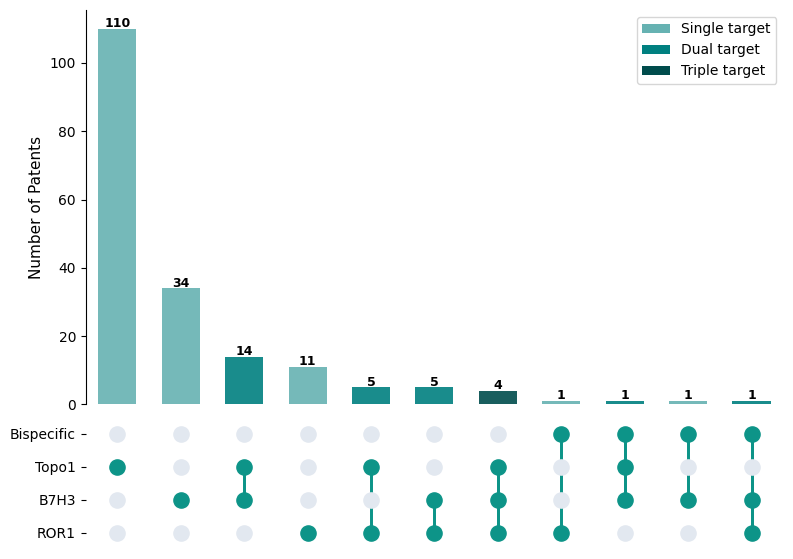

In [85]:
# ── COMBINATION VISUALIZATION ────────────────────────────────
# Bar chart of target combination counts + dot matrix showing which targets are included in each combination
fig, (ax_bar, ax_matrix) = plt.subplots(
    2, 1, figsize=(9, 7),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

combos = combo_counts.index.tolist()
counts_list = combo_counts.values.tolist()
targets = ['ROR1', 'B7H3', 'Topo1', 'Bispecific']

def get_color(combo):
    n_targets = len([t for t in ['ROR1', 'B7H3', 'Topo1'] if t in combo])
    if n_targets == 1:
        return "#66b2b2"
    elif n_targets == 2:
        return "#008080"
    else:
        return "#004c4c"

bar_colors = [get_color(c) for c in combos]

# top panel: bar chart
ax_bar.bar(range(len(combos)), counts_list, color=bar_colors, alpha=0.9, width=0.6)
for i, v in enumerate(counts_list):
    ax_bar.text(i, v + 0.5, str(v), ha='center', fontsize=9, fontweight='bold')
ax_bar.set_ylabel('Number of Patents', fontsize=11)
ax_bar.set_xticks([])
ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)
ax_bar.set_xlim(-0.5, len(combos) - 0.5)

# bottom panel: dot matrix
for col_i, combo in enumerate(combos):
    active = [t for t in targets if t in combo]
    for row_i, target in enumerate(targets):
        if target in active:
            ax_matrix.scatter(col_i, row_i, s=120, color='#0D9488', zorder=5)
            if len(active) > 1:
                first = targets.index(active[0])
                last = targets.index(active[-1])
                ax_matrix.plot([col_i, col_i], [first, last],
                               color='#0D9488', linewidth=2, zorder=4)
        else:
            ax_matrix.scatter(col_i, row_i, s=120, color='#E2E8F0', zorder=5)

ax_matrix.set_yticks(range(len(targets)))
ax_matrix.set_yticklabels(targets, fontsize=10)
ax_matrix.set_xticks([])
ax_matrix.set_xlim(-0.5, len(combos) - 0.5)
ax_matrix.set_ylim(-0.5, len(targets) - 0.5)
ax_matrix.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

legend_elements = [
    Patch(facecolor='#66b2b2', label='Single target'),
    Patch(facecolor='#008080', label='Dual target'),
    Patch(facecolor='#004c4c', label='Triple target')
]
ax_bar.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../../data/images/05b_IP_competitor_combinations.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [84]:
# ── Look deeper on the bispecifics ─────────────
# Extract title from biblio (same structure as owners extraction)
def extract_title(biblio):
    try:
        if isinstance(biblio, str):
            biblio = ast.literal_eval(biblio)
        return biblio.get('invention_title', [{}])[0].get('text', 'N/A') \
            if isinstance(biblio.get('invention_title'), list) \
            else biblio.get('invention_title', 'N/A')
    except:
        return 'N/A'

#Extract priority date too
def extract_priority_date_inline(biblio):
    try:
        if isinstance(biblio, str):
            biblio = ast.literal_eval(biblio)
        return biblio['priority_claims']['earliest_claim']['date']
    except:
        return None

bispecific_analogs = df_full[df_full['bispecific_flag'] == True].copy()
bispecific_analogs['title'] = bispecific_analogs['biblio'].apply(extract_title)
bispecific_analogs['priority_year'] = pd.to_datetime(
    bispecific_analogs['biblio'].apply(extract_priority_date_inline),
    errors='coerce'
).dt.year

print(f"Bispecific architectural analogs: {len(bispecific_analogs)}\n")
print("=" * 80)

for _, row in bispecific_analogs.iterrows():
    owner_str = ', '.join(row['owners']) if isinstance(row['owners'], list) else str(row['owners'])
    targets_hit = []
    if row['ror1_confidence'] in ['high', 'medium']: targets_hit.append(f"ROR1 ({row['ror1_confidence']})")
    if row['b7h3_confidence'] in ['high', 'medium']: targets_hit.append(f"B7H3 ({row['b7h3_confidence']})")
    if row['topo1_confidence'] in ['high', 'medium']: targets_hit.append(f"Topo-I ({row['topo1_confidence']})")

    print(f"\nLens ID:        {row['lens_id']}")
    print(f"Title:          {row['title']}")
    print(f"Priority Year:  {int(row['priority_year']) if pd.notna(row['priority_year']) else 'N/A'}")
    print(f"Owner(s):       {owner_str}")
    print(f"Pub Type:       {row['publication_type']}")
    print(f"Targets hit:    {' | '.join(targets_hit)}")
    print(f"\nBispecific reasoning:")
    print(f"  {row['bispecific_reasoning']}")
    print("-" * 80)

Bispecific architectural analogs: 4


Lens ID:        148-515-645-112-879
Title:          Conjugates of Biomolecule and Use Thereof
Priority Year:  2017
Owner(s):       YAFEI SHANGHAI BIOLOG MEDICINE SCIENCE & TECHNOLOG
Pub Type:       PATENT_APPLICATION
Targets hit:    ROR1 (high)

Bispecific reasoning:
  Claim 62 describes a bispecific antibody with one arm targeting ROR1, meeting the criteria for a bispecific construct.
--------------------------------------------------------------------------------

Lens ID:        077-627-115-888-779
Title:          Tandem repeat cancer-targeting peptides for molecular conjugation or engineering and uses thereof in cancer theranostics
Priority Year:  2020
Owner(s):       CHANG GUNG MEMORIAL HOSPITAL
Pub Type:       GRANTED_PATENT
Targets hit:    B7H3 (high) | Topo-I (high)

Bispecific reasoning:
  The claims describe a bispecific anti-cancer antibody targeting B7-H3, meeting the criteria for a bispecific construct with one arm targeting B7-H3.
---

**None of the 4 bispecific analogs represent tight architectural threats to NEOK001:**

| Owner | Title | Priority | Target Hits | Status | Assessment |
|-------|-------|----------|-------------|--------|------------|
| Yafei Shanghai | "Conjugates of Biomolecule and Use Thereof" | 2017 | ROR1 only | Application | Broad-scope application; ROR1 in dependent claim 62, not primary scope |
| Chang Gung Memorial Hospital | "Tandem repeat cancer-targeting peptides…" | 2020 | B7H3 + Topo-I | **Granted** | Peptide-drug conjugate platform, different modality from ADC |
| Fortvita Biologics (Singapore) | "Bispecific Antibody Binding EGFR and B7-H3" | 2022 | B7H3 only | Application | Different second arm (EGFR, not NEOK001's ROR1) |
| Nationwide Children's Hospital | "CATVERT/CATVERN Linkers" | 2019 | ROR1 + B7H3 | Application | Cell engager (T-cell/NK platform), not an ADC |

**Priority year context:**
- **Yafei (2017)** — predates ABL Bio's 2019 foundational filings, but ROR1 appears only in dependent claim 62, suggesting it is not the primary invention focus
- **Nationwide Children's (2019)** — same priority year as ABL Bio, but different modality (cell engager vs ADC)
- **Chang Gung (2020) and Fortvita (2022)** — both filed AFTER ABL Bio's 2019 ROR1/B7-H3 antibody arm patents, so ABL Bio has priority in the antibody space

**Observations:**

1. **Only 1 of 4 is granted** — Chang Gung Memorial's peptide-drug conjugate, which is a mechanistically distinct modality from antibody-based ADCs

2. **Different modalities dominate** - Nationwide Children's CATVERT/CATVERN is a T-cell/NK engager platform (cell therapy linkers), not an ADC. Chang Gung's peptide conjugate is also distinct from traditional ADC architecture

3. **Different target pairings** - Fortvita's bispecific pairs B7-H3 with EGFR, not ROR1. The dual-target combination doesn't match NEOK001's design

4. **ABL Bio has priority in the antibody space** — ABL Bio's 2019 ROR1 and B7-H3 antibody arm patents predate both Chang Gung and Fortvita filings. Only the Yafei 2017 filing predates ABL Bio, but its ROR1 claim is narrow (dependent claim 62, not independent)

Overall, validates NEOK001's first-in-class positioning at the US patent level

---

## 3. Ownership Analysis (Full Competitor Set)

Merge competitor flags with bibliographic metadata (owners, publication type, priority dates), consolidate duplicate owner entities, then analyze top competitor owners


In [51]:
# load raw US patent metadata
df_raw = pd.read_json("../../data/raw/US-enforced-patents.jsonl", lines=True)

df_full = competitor_df.merge(
    df_raw[['lens_id', 'biblio', 'publication_type']],
    on='lens_id', how='left'
)

def extract_all_owners(biblio):
    try:
        owners = biblio['parties']['owners_all']
        return [o['extracted_name']['value'] for o in owners]
    except:
        try:
            applicants = biblio['parties']['applicants']
            return [a['extracted_name']['value'] for a in applicants]
        except:
            return []

df_full['owners'] = df_full['biblio'].apply(extract_all_owners)

print(f"Full merged dataset: {df_full.shape}")
print(f"Competitor patents: {df_full['competitor_flag'].sum()}")

Full merged dataset: (1057, 19)
Competitor patents: 187


In [74]:
# explode owners (patents with multiple owners get one row per owner)
df_exploded = df_full.explode('owners')

# ── OWNER NAME CONSOLIDATION ─────────────────────────────────
# Some owners appear under multiple legal entity names in Lens records
# (parent company + subsidiary, or formal + informal variants).
# Consolidate to avoid double-counting.

name_consolidation = {
    # Novartis group
    'NOVARTIS INSTITUTES FOR BIOMEDICAL RESEARCH INC': 'NOVARTIS AG',
    # University of Pennsylvania — formal vs informal
    'THE TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA': 'UNIV PENNSYLVANIA',
    # Minghui group (Shanghai + Hangzhou entities)
    'MINGHUI PHARMACEUTICAL SHANGHAI LTD': 'MINGHUI PHARMACEUTICAL',
    'MINGHUI PHARMACEUTICAL HANGZHOU LTD': 'MINGHUI PHARMACEUTICAL',
}

# Intentionally NOT consolidated:
# - ASTRAZENECA AB vs ASTRAZENECA UK LTD (different filing strategies, see Report 5b §4)
# - MERCK SHARP & DOHME vs MERCK SHARP & DOHME LLC (legally distinct)
# - SHANGHAI HENGRUI vs JIANGSU HENGRUI (related group, independent filers)

df_exploded['owners'] = df_exploded['owners'].replace(name_consolidation)

# ── DEDUPLICATE (owner, lens_id) PAIRS ───────────────────────
# After consolidation, some patents co-assigned to multiple entities that
# now map to the same consolidated name would appear as duplicate rows.
# Drop those so each (owner, lens_id) pair is counted once.
df_exploded = df_exploded.drop_duplicates(subset=['owners', 'lens_id'])

# competitor owner counts (using consolidated, deduplicated names)
competitor_owners = df_exploded[df_exploded['competitor_flag'] == True]
counts = competitor_owners['owners'].value_counts()

print(f"Total competitor patents: {competitor_df['competitor_flag'].sum()}")
print(f"Owner-patent relationships (some patents have multiple owners): {counts.sum()}")
print(f"Unique competitor owners (after consolidation): {len(counts)}")
print(f"\nTop 20 competitor owners:")
print(counts.head(20))

Total competitor patents: 187
Owner-patent relationships (some patents have multiple owners): 265
Unique competitor owners (after consolidation): 200

Top 20 competitor owners:
owners
DAIICHI SANKYO COMPANY LIMITED                 11
SHANGHAI HENGRUI PHARMACEUTICAL CO. LTD         7
JIANGSU HENGRUI MEDICINE CO. LTD                6
BIO-THERA SOLUTIONS LTD                         4
NOVARTIS AG                                     4
SYSTIMMUNE INC                                  4
BAILI-BIO (CHENGDU) PHARMACEUTICAL CO. LTD      4
UNIV PENNSYLVANIA                               4
ASTRAZENECA UK LIMITED                          3
ZYMEWORKS BC INC                                3
SHANGHAI HANSOH BIOMEDICAL CO. LTD              3
JIANGSU HANSOH PHARMACEUTICAL GROUP CO. LTD     3
LIGACHEM BIOSCIENCES INC                        3
BEONE MEDICINES I GMBH                          2
BEIGENE LTD                                     2
ALTEOGEN INC                                    2
REMEGEN CO. LTD 

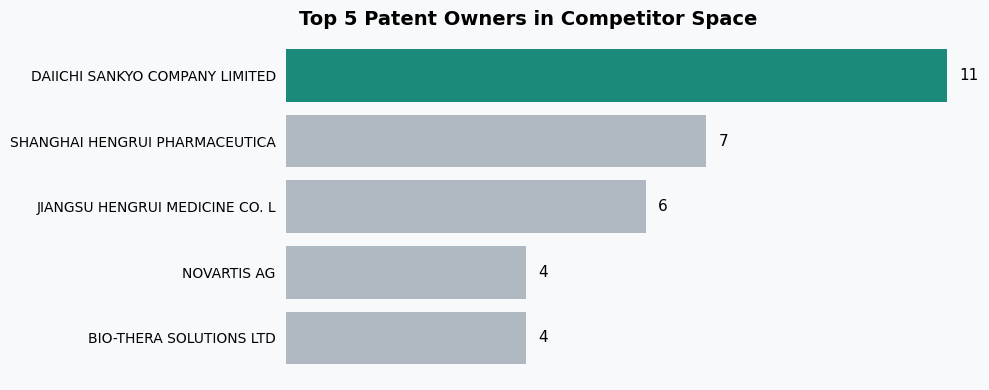

In [75]:
# ── TOP 5 VISUALIZATION ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

top5 = counts.head(5).sort_values()
top5.index = [name[:30] for name in top5.index]

bar_colors = ['#B0B8C1'] * len(top5)
bar_colors[-1] = '#1B8A7A'

bars = ax.barh(top5.index, top5.values, color=bar_colors)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')

for i, v in enumerate(top5.values):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=11)

ax.set_title('Top 5 Patent Owners in Competitor Space',
             fontsize=14, weight='bold', x=0.35, y=1)

ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_facecolor('#F7F9FB')
fig.patch.set_facecolor('#F7F9FB')

plt.tight_layout()
plt.savefig('../../data/images/05b_IP_top5_competitor_owners.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [76]:
# ── OWNER TARGET BREAKDOWN ───────────────────────────────────
comp_targets = df_exploded[df_exploded['competitor_flag'] == True][['owners', 'lens_id']].merge(
    competitor_df[['lens_id', 'ror1_confidence', 'b7h3_confidence', 'topo1_confidence', 'bispecific_flag']],
    on='lens_id', how='left'
)

comp_targets['ROR1'] = comp_targets['ror1_confidence'].isin(['high', 'medium']).astype(int)
comp_targets['B7H3'] = comp_targets['b7h3_confidence'].isin(['high', 'medium']).astype(int)
comp_targets['Topo1'] = comp_targets['topo1_confidence'].isin(['high', 'medium']).astype(int)
comp_targets['Bispecific'] = comp_targets['bispecific_flag'].astype(int)

owner_targets = comp_targets.groupby('owners')[['ROR1', 'B7H3', 'Topo1', 'Bispecific']].sum()
owner_targets['Total_patents'] = comp_targets.groupby('owners')['lens_id'].nunique()
owner_targets = owner_targets.sort_values('Total_patents', ascending=False)

print(owner_targets.head(15))

owner_targets.to_csv('../../data/processed/technical_space_competitors.csv')


                                                ROR1  B7H3  Topo1  Bispecific  \
owners                                                                          
DAIICHI SANKYO COMPANY LIMITED                     0     7      4           0   
SHANGHAI HENGRUI PHARMACEUTICAL CO. LTD            0     4      5           0   
JIANGSU HENGRUI MEDICINE CO. LTD                   0     3      5           0   
BAILI-BIO (CHENGDU) PHARMACEUTICAL CO. LTD         0     1      4           0   
BIO-THERA SOLUTIONS LTD                            1     2      4           0   
UNIV PENNSYLVANIA                                  2     4      0           0   
SYSTIMMUNE INC                                     0     1      4           0   
NOVARTIS AG                                        2     3      1           0   
ASTRAZENECA UK LIMITED                             0     0      3           0   
JIANGSU HANSOH PHARMACEUTICAL GROUP CO. LTD        0     1      3           0   
LIGACHEM BIOSCIENCES INC    

**Top competitor owners (after entity consolidation):**

1. **Daiichi Sankyo (11 patents)** - B7-H3 + Topo-I dominant, consistent with DXd platform and I-DXd (ifinatamab deruxtecan) development
2. **Shanghai Hengrui + Jiangsu Hengrui (13 combined)** — Chinese pharma with heavy Topo-I + B7-H3 filings
3. **Bio-Thera, SystImmune, Baili-Bio** — Chinese/Asian biotech cluster
4. **Novartis** — only filer hitting all three targets (ROR1, B7-H3, Topo-I), though not in a single bispecific construct

**Chinese pharma cluster ~11% of competitor patents** - consistent with composition-heavy filing pattern observed in 5b-1


---

## 4. Antibody-Relevant Competitors - ROR1 and B7-H3 Patents

While Topo-I is the most common target hit, Topo-I alone represents a payload-class overlap rather than a targeting overlap. 

The architecturally relevant patent subset for NEOK001 is patents that claim **ROR1 or B7-H3 antibodies**; these are the filings that could create blocking or design-around pressure at the targeting level (the core)

**Subset definition:** patents with ROR1 OR B7-H3 at medium or high confidence (ignoring Topo-I-only patents and bispecifics without a target hit, the latter are already filtered out by the above correction)

In [77]:
# filter to antibody-relevant subset
antibody_relevant_ids = df_full[
    df_full['ror1_confidence'].isin(['high', 'medium']) |
    df_full['b7h3_confidence'].isin(['high', 'medium'])
]['lens_id'].tolist()

antibody_competitors = df_full[df_full['lens_id'].isin(antibody_relevant_ids)].copy()
antibody_exploded = df_exploded[df_exploded['lens_id'].isin(antibody_relevant_ids)].copy()

print(f"Antibody-relevant competitor patents: {len(antibody_competitors)}")
print()

# breakdown
antibody_competitors['ROR1_hit'] = antibody_competitors['ror1_confidence'].isin(['high','medium'])
antibody_competitors['B7H3_hit'] = antibody_competitors['b7h3_confidence'].isin(['high','medium'])
antibody_competitors['Topo1_hit'] = antibody_competitors['topo1_confidence'].isin(['high','medium'])

print("Breakdown by antibody target:")
print(f"  ROR1 only:           {((antibody_competitors['ROR1_hit']) & (~antibody_competitors['B7H3_hit'])).sum()}")
print(f"  B7-H3 only:          {((~antibody_competitors['ROR1_hit']) & (antibody_competitors['B7H3_hit'])).sum()}")
print(f"  ROR1 + B7-H3 (dual): {((antibody_competitors['ROR1_hit']) & (antibody_competitors['B7H3_hit'])).sum()}")
print()
print("How many also claim Topo-I payload:")
print(f"  ROR1 + Topo-I:         {((antibody_competitors['ROR1_hit']) & (~antibody_competitors['B7H3_hit']) & (antibody_competitors['Topo1_hit'])).sum()}")
print(f"  B7-H3 + Topo-I:        {((~antibody_competitors['ROR1_hit']) & (antibody_competitors['B7H3_hit']) & (antibody_competitors['Topo1_hit'])).sum()}")
print(f"  ROR1 + B7-H3 + Topo-I: {((antibody_competitors['ROR1_hit']) & (antibody_competitors['B7H3_hit']) & (antibody_competitors['Topo1_hit'])).sum()}")

Antibody-relevant competitor patents: 78

Breakdown by antibody target:
  ROR1 only:           18
  B7-H3 only:          50
  ROR1 + B7-H3 (dual): 10

How many also claim Topo-I payload:
  ROR1 + Topo-I:         5
  B7-H3 + Topo-I:        15
  ROR1 + B7-H3 + Topo-I: 4


**Antibody-relevant competitor landscape:**

| Category | Count |
|----------|-------|
| ROR1 antibody patents | 18 |
| B7-H3 antibody patents | 50 |
| Dual ROR1 + B7-H3 patents | 10 |
| Unique antibody-relevant patents | 78 |

**Observation:**

- **B7-H3 antibody space is >2x more crowded than ROR1** — consistent with B7-H3 being a more clinically mature target (DS-7300a, MGC018, etc.)
- **10 patents claim have both ROR1 and B7-H3**

In [78]:
# antibody-relevant owner counts
antibody_counts = antibody_exploded['owners'].value_counts()

print(f"Unique owners with antibody-relevant patents: {len(antibody_counts)}")
print(f"Total owner-patent relationships: {antibody_counts.sum()}")
print()
print(f"Top 20 antibody-relevant competitor owners:")
print(antibody_counts.head(20))

Unique owners with antibody-relevant patents: 93
Total owner-patent relationships: 111

Top 20 antibody-relevant competitor owners:
owners
DAIICHI SANKYO COMPANY LIMITED                                                                          7
SHANGHAI HENGRUI PHARMACEUTICAL CO. LTD                                                                 4
UNIV PENNSYLVANIA                                                                                       4
JIANGSU HENGRUI MEDICINE CO. LTD                                                                        3
NOVARTIS AG                                                                                             3
BIO-THERA SOLUTIONS LTD                                                                                 2
NBE-THERAPEUTICS AG                                                                                     2
MEDILINK THERAPEUTICS (SUZHOU) CO. LTD                                                                  1
BEONE MEDICIN

In [79]:
# target breakdown per owner (ROR1 vs B7-H3)
antibody_targets = antibody_exploded[['owners', 'lens_id']].merge(
    antibody_competitors[['lens_id', 'ROR1_hit', 'B7H3_hit', 'Topo1_hit']],
    on='lens_id', how='left'
)

antibody_targets['ROR1'] = antibody_targets['ROR1_hit'].astype(int)
antibody_targets['B7H3'] = antibody_targets['B7H3_hit'].astype(int)
antibody_targets['Topo1'] = antibody_targets['Topo1_hit'].astype(int)

owner_ab_targets = antibody_targets.groupby('owners')[['ROR1', 'B7H3', 'Topo1']].sum()
owner_ab_targets['Total_patents'] = antibody_exploded.groupby('owners')['lens_id'].nunique()
owner_ab_targets = owner_ab_targets.sort_values('Total_patents', ascending=False)

print(owner_ab_targets.head(15))

owner_ab_targets.to_csv('../../data/processed/antibody_competitors.csv')


                                                    ROR1  B7H3  Topo1  \
owners                                                                  
DAIICHI SANKYO COMPANY LIMITED                         0     7      0   
SHANGHAI HENGRUI PHARMACEUTICAL CO. LTD                0     4      2   
UNIV PENNSYLVANIA                                      2     4      0   
NOVARTIS AG                                            2     3      0   
JIANGSU HENGRUI MEDICINE CO. LTD                       0     3      2   
NBE-THERAPEUTICS AG                                    2     0      0   
BIO-THERA SOLUTIONS LTD                                1     2      2   
PDX PHARMACEUTICALS INC                                0     1      0   
SHANGHAI HANSOH BIOMEDICAL CO. LTD                     0     1      1   
SHANGHAI FUDAN-ZHANGJIANG BIO-PHARMACEUTICAL CO...     0     1      1   
RZNOMICS INC                                           0     1      0   
RESEARCH INSTITUTE AT NATIONWIDE CHILDREN'S HOS... 

- **Chinese pharma dominates B7-H3** — Shanghai Hengrui and Jiangsu Hengrui are heavily represented in B7-H3 filings
- **Daiichi Sankyo leads B7-H3 volume** (I-DXd / ifinatamab deruxtecan program)
- **ROR1 filings are more distributed** 

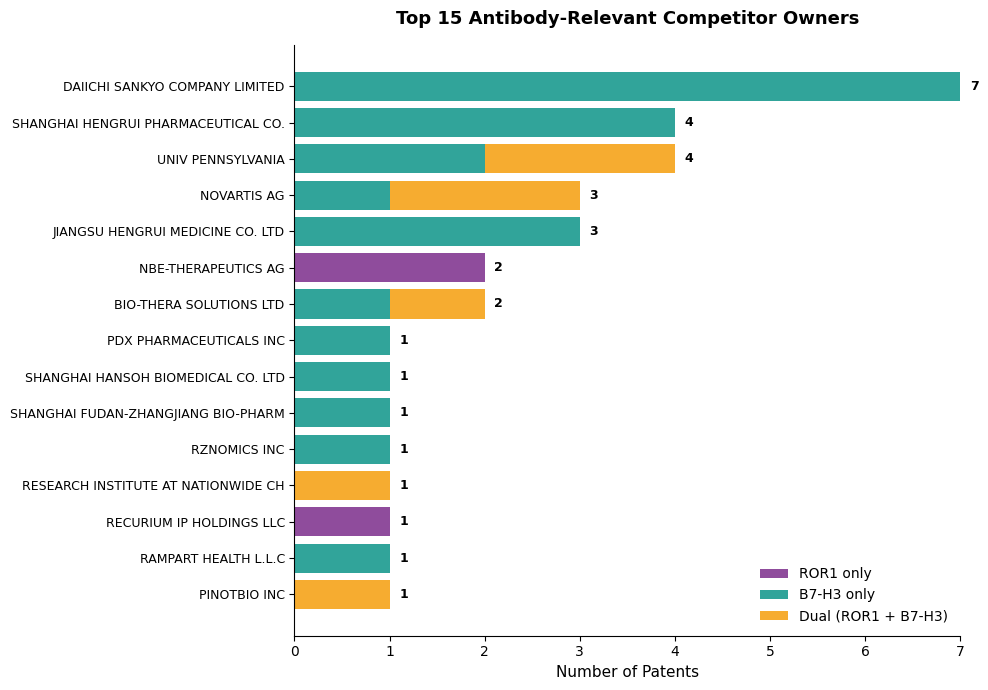

In [81]:
# ── VISUALIZE TOP 15 ANTIBODY COMPETITORS ────────────────────
# x-axis = unique patent count
# color segments show: ROR1-only / B7H3-only / dual ROR1+B7H3

# build three mutually exclusive counts per owner
antibody_targets_dedup = antibody_targets.drop_duplicates(subset=['owners', 'lens_id']).copy()
antibody_targets_dedup['ROR1_only'] = (
    (antibody_targets_dedup['ROR1'] == 1) & (antibody_targets_dedup['B7H3'] == 0)
).astype(int)
antibody_targets_dedup['B7H3_only'] = (
    (antibody_targets_dedup['ROR1'] == 0) & (antibody_targets_dedup['B7H3'] == 1)
).astype(int)
antibody_targets_dedup['Dual'] = (
    (antibody_targets_dedup['ROR1'] == 1) & (antibody_targets_dedup['B7H3'] == 1)
).astype(int)

owner_ab_mix = antibody_targets_dedup.groupby('owners')[
    ['ROR1_only', 'B7H3_only', 'Dual']
].sum()
owner_ab_mix['Total'] = owner_ab_mix.sum(axis=1)
owner_ab_mix = owner_ab_mix.sort_values('Total', ascending=False)

top15 = owner_ab_mix.head(15).copy()
top15.index = [name[:35] for name in top15.index]

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = list(range(len(top15)))[::-1]  # reverse so largest at top

ax.barh(y_pos, top15['ROR1_only'], color='#7B2D8B',
        label='ROR1 only', alpha=0.85)
ax.barh(y_pos, top15['B7H3_only'], left=top15['ROR1_only'],
        color='#0D9488', label='B7-H3 only', alpha=0.85)
ax.barh(y_pos, top15['Dual'], left=top15['ROR1_only'] + top15['B7H3_only'],
        color='#F59E0B', label='Dual (ROR1 + B7-H3)', alpha=0.85)

# annotate total patent count at end of each bar
for i, (idx, row) in enumerate(top15.iterrows()):
    total = row['Total']
    ax.text(total + 0.1, y_pos[i], str(int(total)),
            va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(top15.index, fontsize=9)
ax.set_xlabel('Number of Patents', fontsize=11)
ax.set_title('Top 15 Antibody-Relevant Competitor Owners',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../../data/images/05b_IP_antibody_competitors.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()